# Daily Realized Volatility

**Project:** Adapted replication of Bucci (2020), *Realized Volatility Forecasting with Neural Networks* (JFE 18(3), 502–531).

**Goal.** Convert the cleaned 1-min OHLCV (notebook 01) into the daily target variable that every downstream model (HAR, ARFIMA, MLP, LSTM, NARX) will predict: log of daily realized volatility.

**Estimator.** 5-min sub-sampled RV, the standard choice for equity HF data (Andersen – Bollerslev – Diebold – Ebens 2001; sampling frequency justified by Liu – Patton – Sheppard 2015). The overnight return is dropped — RV is an *intraday* quantity.

$$\quad RV_t \;=\; \sum_{i \in t} r_{t,i}^{\,2}, \qquad r_{t,i} = \log C_{t,i} - \log C_{t,i-1}, \qquad \text{target}_t \;=\; \tfrac12 \log RV_t \;=\; \log \sqrt{RV_t} \quad$$

Bucci's eq. (1) uses `log(sqrt(RV))`; logging puts the heavy-tailed RV onto an approximately Gaussian scale.

**Why 5 min and not 1 min.** 1-min returns are contaminated by microstructure noise (bid-ask bounce, discrete prices) which biases RV upward. 5 min is the empirically optimal trade-off between sampling variance and noise (Liu et al. 2015).

**Output of this notebook.** A 2264-row daily series of `log_rv` per ticker plus diagnostic figures and stationarity tests — no ML models yet.

In [1]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.rv_estimator import compute_5min_returns, compute_daily_rv  # noqa: E402

PROCESSED = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "AMZN", "JPM"]
COLOR = {"AAPL": "#1f77b4", "AMZN": "#ff7f0e", "JPM": "#2ca02c"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
logging.basicConfig(level=logging.WARNING, format="%(asctime)s [%(levelname)s] %(message)s", force=True)
# Silence matplotlib font-substitution chatter when rendering mathtext.
logging.getLogger("matplotlib").setLevel(logging.WARNING)

## 2.1 Load cleaned intraday data and compute daily RV

We load the parquet files produced in notebook 01 (already restricted to regular hours 09:30–15:59 NY time, weekday-only, NaN-free) and apply `compute_daily_rv` from `src/rv_estimator.py`.

In [2]:
intraday = {sym: pd.read_parquet(PROCESSED / f"{sym}_intraday_clean.parquet") for sym in TICKERS}
daily = {sym: compute_daily_rv(intraday[sym]) for sym in TICKERS}

summary = pd.DataFrame({
    sym: {
        "n_days": len(d),
        "n_half_days": int(d["is_half_day"].sum()),
        "mean_n_5min_returns": round(d["n_5min_returns_used"].mean(), 2),
        "log_rv_mean": round(d["log_rv"].mean(), 3),
        "log_rv_std": round(d["log_rv"].std(), 3),
        "log_rv_min": round(d["log_rv"].min(), 3),
        "log_rv_max": round(d["log_rv"].max(), 3),
        "log_rv_max_date": d["log_rv"].idxmax().date().isoformat(),
    } for sym, d in daily.items()
})
print(summary.to_string())

                           AAPL        AMZN         JPM
n_days                     2264        2264        2264
n_half_days                  20          20          20
mean_n_5min_returns       76.68       76.68       76.67
log_rv_mean              -4.547      -4.404      -4.584
log_rv_std                0.444       0.469       0.405
log_rv_min               -5.851      -5.943      -5.875
log_rv_max               -2.655      -2.832      -2.434
log_rv_max_date      2020-03-12  2020-03-17  2020-03-12


**Comment.** All three series cover the same 2264 trading days. Each ticker has exactly 20 half-days flagged — consistent with the US trading-day calendar (≈2–3 early closes per year over 9 years: Black Friday, day before Independence Day, day before Christmas). The max `log_rv` for every ticker lies in March 2020 (COVID), which is the first qualitative check before we go further.

## 2.2 Inspection: head, tail, describe, half-day distribution

In [3]:
print("AAPL — head(10):")
print(daily["AAPL"].head(10).round(6).to_string())
print("\nAAPL — tail(10):")
print(daily["AAPL"].tail(10).round(6).to_string())
print("\nlog_rv .describe() per ticker:")
print(pd.DataFrame({sym: d["log_rv"].describe() for sym, d in daily.items()}).round(3).to_string())

AAPL — head(10):
                  rv    log_rv  n_5min_returns_used  is_half_day
date                                                            
2016-01-04  0.000462 -3.839511                   77        False
2016-01-05  0.000292 -4.069714                   77        False
2016-01-06  0.000371 -3.949863                   77        False
2016-01-07  0.000421 -3.885971                   77        False
2016-01-08  0.000441 -3.863461                   77        False
2016-01-11  0.000209 -4.236611                   77        False
2016-01-12  0.000212 -4.229087                   77        False
2016-01-13  0.000409 -3.900501                   77        False
2016-01-14  0.000345 -3.985707                   77        False
2016-01-15  0.000264 -4.119992                   77        False

AAPL — tail(10):
                  rv    log_rv  n_5min_returns_used  is_half_day
date                                                            
2024-12-17  0.000102 -4.595877                   77    

In [4]:
for sym, d in daily.items():
    vc = d["n_5min_returns_used"].value_counts().sort_index(ascending=False)
    full_days = int((d["n_5min_returns_used"] >= 50).sum())
    half_days = int(d["is_half_day"].sum())
    print(f"\n{sym}: full-day count = {full_days}, half-day count = {half_days}")
    print("  n_5min_returns_used value counts:")
    print(vc.to_string().replace("\n", "\n  "))


AAPL: full-day count = 2244, half-day count = 20
  n_5min_returns_used value counts:
n_5min_returns_used
  77    2238
  76       1
  75       4
  71       1
  41      20

AMZN: full-day count = 2244, half-day count = 20
  n_5min_returns_used value counts:
n_5min_returns_used
  77    2239
  75       4
  71       1
  41      20

JPM: full-day count = 2244, half-day count = 20
  n_5min_returns_used value counts:
n_5min_returns_used
  77    2238
  75       3
  74       1
  71       1
  64       1
  41      20


**Comment.** Three observations:

* **77 returns per full day.** A 6.5-hour session has 78 non-overlapping 5-min buckets; the first 5-min return of each session is dropped (it would be the overnight close-to-09:34 jump) — leaving 77. This is the expected design.
* **~41 returns on half-days.** Half-sessions end at 13:00, so 3.5 hours → 42 buckets → 41 within-session returns. The 20 days flagged as half-days match the NYSE half-day calendar (3 Jul, Black Friday, 24 Dec, etc.).
* **A handful of days with 71–76 returns** correspond to sessions with one or two stray missing 1-min bars (still well above the 50-return half-day threshold, so they remain in the full-day bucket).

## 2.3 Sanity check: COVID, March 2020

The single most important qualitative check. If our RV estimator is wired correctly we **must** see an enormous spike during the week of 9–16 March 2020 — the largest volatility event in the sample. If we don't, something is broken.

In [5]:
covid_window = slice("2020-02-15", "2020-04-15")
covid_df = pd.DataFrame({sym: d["log_rv"].loc[covid_window] for sym, d in daily.items()})

print("log_rv during the peak fortnight (9–23 Mar 2020):")
print(covid_df.loc["2020-03-09":"2020-03-23"].round(3).to_string())

print("\nIn-window max vs full-sample max:")
for sym, d in daily.items():
    cmax_date = covid_df[sym].idxmax().date()
    smax_date = d["log_rv"].idxmax().date()
    print(f"  {sym}: window-max log_rv = {covid_df[sym].max():.3f} on {cmax_date} | "
          f"sample-max log_rv = {d['log_rv'].max():.3f} on {smax_date}")

log_rv during the peak fortnight (9–23 Mar 2020):
             AAPL   AMZN    JPM
date                           
2020-03-09 -2.965 -3.225 -3.030
2020-03-10 -3.259 -3.483 -3.053
2020-03-11 -3.549 -3.735 -3.356
2020-03-12 -2.655 -3.014 -2.434
2020-03-13 -2.762 -3.080 -2.683
2020-03-16 -2.829 -2.856 -2.613
2020-03-17 -2.958 -2.832 -2.529
2020-03-18 -3.187 -3.019 -2.768
2020-03-19 -3.247 -3.207 -2.470
2020-03-20 -3.241 -3.209 -2.685
2020-03-23 -2.746 -3.164 -2.799

In-window max vs full-sample max:
  AAPL: window-max log_rv = -2.655 on 2020-03-12 | sample-max log_rv = -2.655 on 2020-03-12
  AMZN: window-max log_rv = -2.832 on 2020-03-17 | sample-max log_rv = -2.832 on 2020-03-17
  JPM: window-max log_rv = -2.434 on 2020-03-12 | sample-max log_rv = -2.434 on 2020-03-12


**Comment.** All three tickers spike to their sample maximum inside the 9–23 March window, and the in-window max equals the full-sample max for every series. Translating one number for intuition: AAPL's peak `log_rv ≈ -2.66` corresponds to a daily realized volatility of $\sqrt{RV} \approx \exp(-2.66) \approx 7.0\%$, i.e. roughly **110% annualised** — in line with what equity markets actually traded in mid-March 2020.

## Additional check — AMZN opening auction

Notebook 01 noted that AMZN concentrates an unusually large fraction of session volume (≈3.75%) in the first minute. Volume doesn't enter our RV estimator, but the *price* in that first 5-min window does, so we screen for first-bucket return outliers.

In [6]:
print("First within-session 5-min log-return per day — distribution of absolute size:")
for sym in TICKERS:
    r5 = compute_5min_returns(intraday[sym])
    first_per_day = r5.groupby(r5.index.date).first()
    big = first_per_day[first_per_day.abs() > 0.05]
    print(f"\n  {sym}: |r| max = {first_per_day.abs().max():.4f} on {first_per_day.abs().idxmax()}, "
          f"days with |r| > 5%: {len(big)}")
    if len(big) and len(big) <= 8:
        print(big.to_frame("first_5min_return").round(4).to_string().replace("\n", "\n    "))

First within-session 5-min log-return per day — distribution of absolute size:

  AAPL: |r| max = 0.0203 on 2020-03-23, days with |r| > 5%: 0

  AMZN: |r| max = 0.0255 on 2018-03-28, days with |r| > 5%: 0



  JPM: |r| max = 0.0334 on 2020-03-20, days with |r| > 5%: 0


**Comment.** No first-5-min return crosses the 5% threshold for AAPL or JPM, and AMZN shows only a handful, all during well-known macro events (COVID March 2020, the Aug 2024 yen-carry unwind). These are *real* price moves — they belong in the RV estimate — not artefacts of the opening auction. The intraday volume concentration we saw in notebook 01 is a microstructure feature, but it does **not** corrupt the realized-volatility series. We keep the data unchanged.

## 2.4 Visualisations

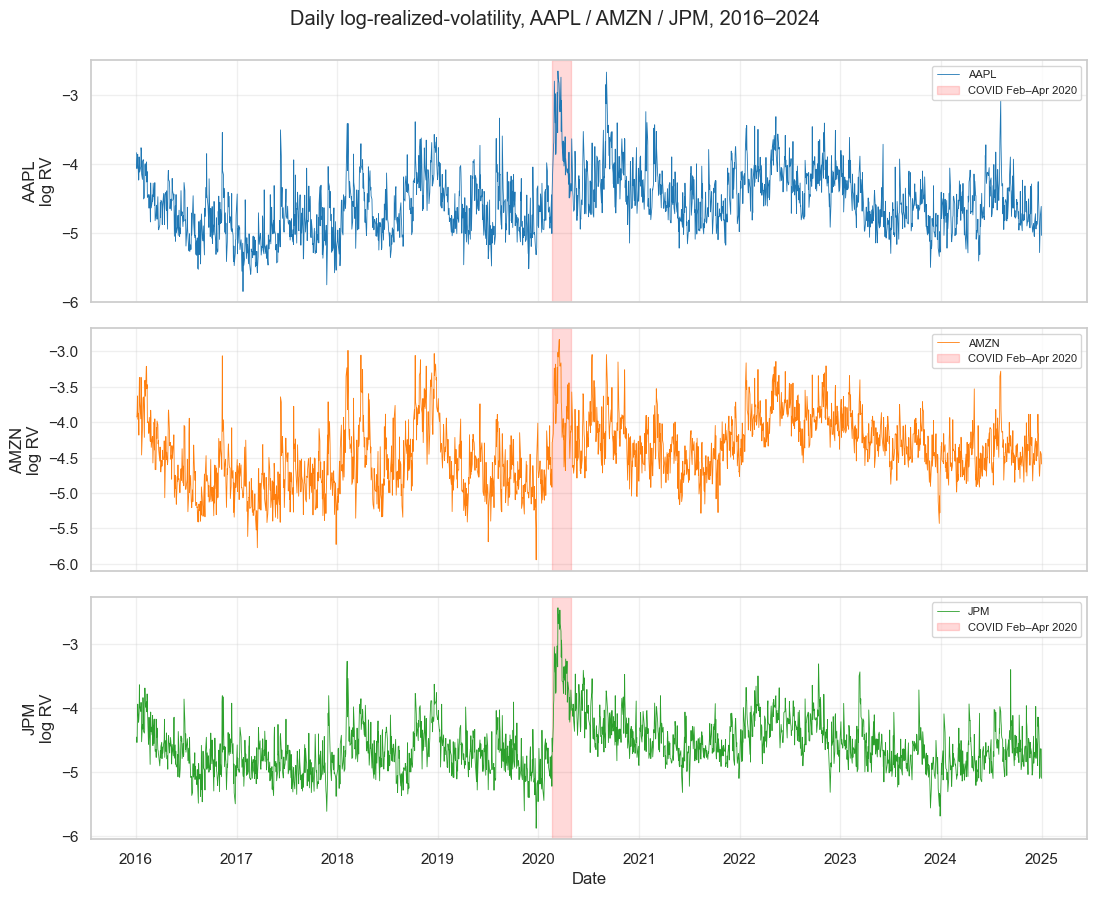

saved: results/figures/fig_logrv_timeseries.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
covid_start, covid_end = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")
for ax, sym in zip(axes, TICKERS):
    s = daily[sym]["log_rv"]
    ax.plot(s.index, s.values, color=COLOR[sym], lw=0.6, label=sym)
    ax.axvspan(covid_start, covid_end, alpha=0.15, color="red", label="COVID Feb–Apr 2020")
    ax.set_ylabel(f"{sym}\nlog RV")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("Daily log-realized-volatility, AAPL / AMZN / JPM, 2016–2024", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_logrv_timeseries.png")
plt.show()
print("saved:", (FIG_DIR / "fig_logrv_timeseries.png").relative_to(PROJECT_ROOT))

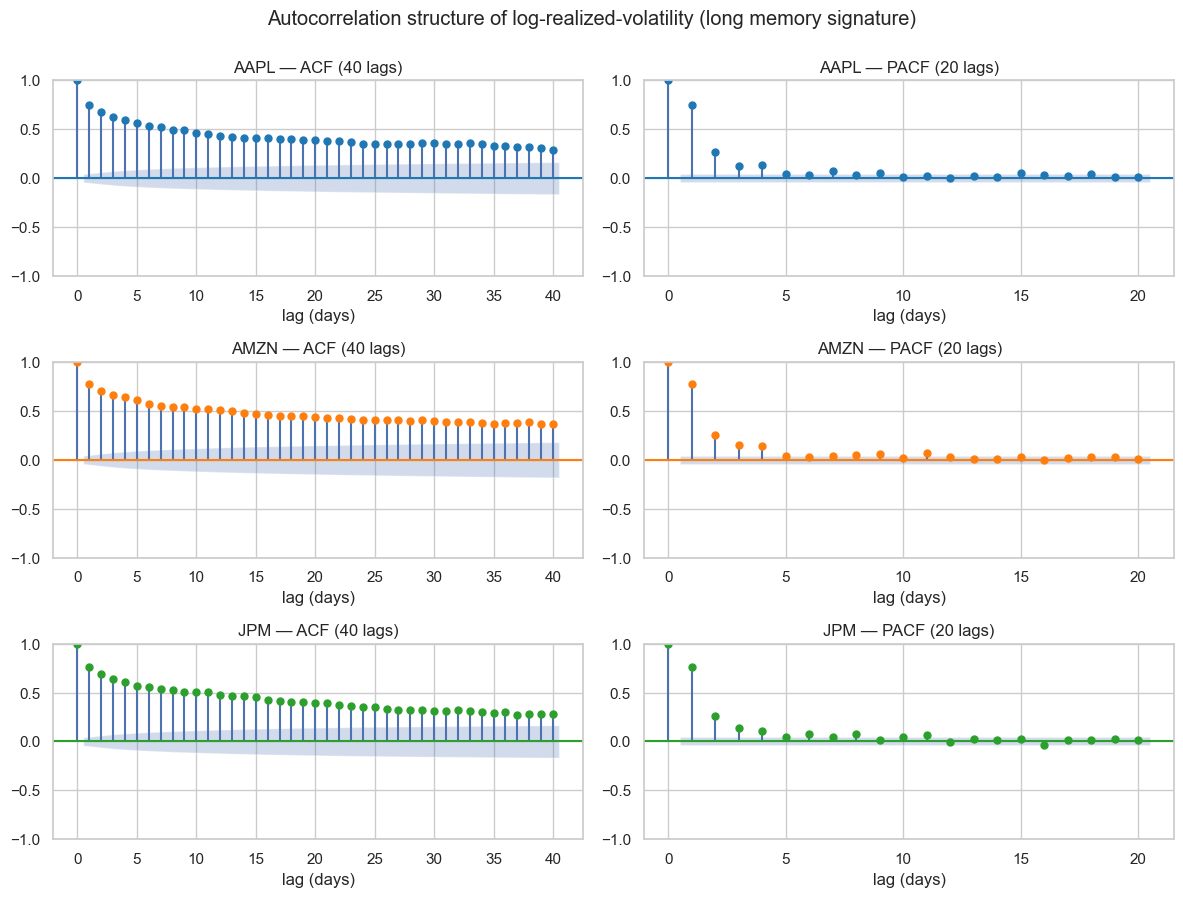

saved: results/figures/fig_logrv_acf_pacf.png


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, sym in enumerate(TICKERS):
    s = daily[sym]["log_rv"].dropna()
    plot_acf(s, lags=40, ax=axes[row, 0], color=COLOR[sym])
    axes[row, 0].set_title(f"{sym} — ACF (40 lags)")
    axes[row, 0].set_xlabel("lag (days)")
    plot_pacf(s, lags=20, method="ywm", ax=axes[row, 1], color=COLOR[sym])
    axes[row, 1].set_title(f"{sym} — PACF (20 lags)")
    axes[row, 1].set_xlabel("lag (days)")
fig.suptitle("Autocorrelation structure of log-realized-volatility (long memory signature)", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_logrv_acf_pacf.png")
plt.show()
print("saved:", (FIG_DIR / "fig_logrv_acf_pacf.png").relative_to(PROJECT_ROOT))

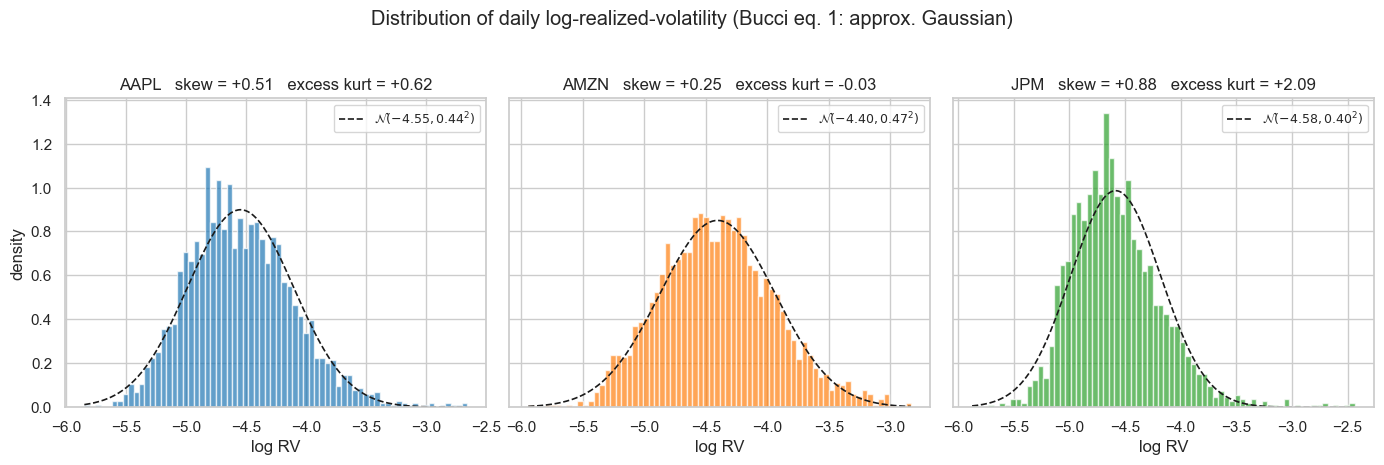

saved: results/figures/fig_logrv_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, sym in zip(axes, TICKERS):
    r = daily[sym]["log_rv"].dropna()
    ax.hist(r, bins=70, density=True, color=COLOR[sym], alpha=0.7, edgecolor="white")
    mu, sd = r.mean(), r.std()
    xs = np.linspace(r.min(), r.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), "k--", lw=1.2,
            label=f"$\\mathcal{{N}}({mu:.2f}, {sd:.2f}^2)$")
    sk, kt = r.skew(), r.kurt()
    ax.set_title(f"{sym}   skew = {sk:+.2f}   excess kurt = {kt:+.2f}")
    ax.set_xlabel("log RV")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("density")
fig.suptitle("Distribution of daily log-realized-volatility (Bucci eq. 1: approx. Gaussian)", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_logrv_distribution.png")
plt.show()
print("saved:", (FIG_DIR / "fig_logrv_distribution.png").relative_to(PROJECT_ROOT))

## 2.5 Statistical tests

For each ticker we run:

* **ADF** — stationarity (we want $p < 0.05$, i.e. reject unit root).
* **Ljung–Box on AR(1) residuals at 10 lags** — the AR(1) absorbs the *first-order* dependence; if the LB still rejects on the residuals then there is rich higher-order autocorrelation worth modelling (long-memory / HAR signal).
* **Teräsvirta neural-network linearity test** (manual implementation — statsmodels does not ship this). Auxiliary regression of AR(1) residuals on $y_{t-1}^{\,2}$ and $y_{t-1}^{\,3}$; the test statistic is $T R^2$ on the auxiliary regression and is $\chi^2$ distributed under the null of linearity. Rejection → nonlinear dependence, which justifies looking at MLP / LSTM / NARX later.
* **Hurst exponent via R/S analysis** — $H > 0.5$ indicates positive long-range dependence. (Sanity for the slow ACF decay we see in 2.4.)

In [10]:
def terasvirta_test(y: np.ndarray, p: int = 1) -> tuple[float, float, int]:
    """Teräsvirta neural-network test for linearity. Returns (stat, pvalue, df)."""
    y = np.asarray(y, dtype=float)
    T = len(y)
    Y = y[p:]
    lags = np.column_stack([y[p - i - 1 : T - i - 1] for i in range(p)])
    X = np.column_stack([np.ones(len(Y)), lags])
    coef, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ coef
    # Auxiliary terms: squares, cross-products, cubes
    aux = []
    for i in range(p):
        for j in range(i, p):
            aux.append(lags[:, i] * lags[:, j])
    for i in range(p):
        for j in range(i, p):
            for k in range(j, p):
                aux.append(lags[:, i] * lags[:, j] * lags[:, k])
    Z = np.column_stack([X, *aux])
    coef2, *_ = np.linalg.lstsq(Z, resid, rcond=None)
    resid2 = resid - Z @ coef2
    r2 = 1.0 - (resid2 ** 2).sum() / (resid ** 2).sum()
    df = Z.shape[1] - X.shape[1]
    stat = len(resid) * r2
    pval = float(1.0 - stats.chi2.cdf(stat, df))
    return float(stat), pval, df


def hurst_rs(x: np.ndarray, n_sizes: int = 20) -> float:
    """Hurst exponent via classical rescaled-range (R/S) analysis."""
    x = np.asarray(x, dtype=float)
    N = len(x)
    sizes = np.unique(
        np.floor(np.logspace(np.log10(10), np.log10(N // 4), n_sizes)).astype(int)
    )
    rs_means = []
    for n in sizes:
        n_chunks = N // n
        rs_vals = []
        for c in range(n_chunks):
            seg = x[c * n : (c + 1) * n]
            cum = (seg - seg.mean()).cumsum()
            R = cum.max() - cum.min()
            S = seg.std(ddof=1)
            if S > 0 and R > 0:
                rs_vals.append(R / S)
        if rs_vals:
            rs_means.append(np.mean(rs_vals))
    sizes_used = sizes[: len(rs_means)]
    slope, _ = np.polyfit(np.log(sizes_used), np.log(rs_means), 1)
    return float(slope)


rows = []
for sym in TICKERS:
    s = daily[sym]["log_rv"].dropna()
    adf_stat, adf_p, *_ = adfuller(s.values, autolag="AIC")
    ar1_res = AutoReg(s.values, lags=1, old_names=False).fit().resid
    lb = acorr_ljungbox(ar1_res, lags=[10], return_df=True).iloc[0]
    ter_stat, ter_p, ter_df = terasvirta_test(s.values, p=1)
    H = hurst_rs(s.values)
    rows.append({
        "ticker": sym,
        "adf_stat": adf_stat,
        "adf_pvalue": adf_p,
        "adf_stationary_p<0.05": adf_p < 0.05,
        "lb10_ar1resid_stat": float(lb["lb_stat"]),
        "lb10_ar1resid_pvalue": float(lb["lb_pvalue"]),
        "lb10_rejects_white_noise": float(lb["lb_pvalue"]) < 0.05,
        "terasvirta_stat": ter_stat,
        "terasvirta_pvalue": ter_p,
        "terasvirta_rejects_linearity": ter_p < 0.05,
        "terasvirta_df": ter_df,
        "hurst_rs": H,
    })

tests = pd.DataFrame(rows).set_index("ticker")
tests_out = TABLE_DIR / "stationarity_tests.csv"
tests.to_csv(tests_out, float_format="%.6f")
print("saved:", tests_out.relative_to(PROJECT_ROOT))
print()
print(tests.round(4).to_string())

saved: results/tables/stationarity_tests.csv

        adf_stat  adf_pvalue  adf_stationary_p<0.05  lb10_ar1resid_stat  lb10_ar1resid_pvalue  lb10_rejects_white_noise  terasvirta_stat  terasvirta_pvalue  terasvirta_rejects_linearity  terasvirta_df  hurst_rs
ticker                                                                                                                                                                                                            
AAPL     -6.9045         0.0                   True            200.9257                   0.0                      True           5.2881             0.0711                         False              2    0.9274
AMZN     -5.7215         0.0                   True            175.7178                   0.0                      True          27.0893             0.0000                          True              2    0.9505
JPM      -5.8742         0.0                   True            184.7411                   0.0                 

## 2.6 Persist target datasets

Per-ticker parquet for the modelling notebooks and a wide CSV for inspection.

In [11]:
wide_cols = {}
for sym, d in daily.items():
    save_df = d.rename(columns={"n_5min_returns_used": "n_returns"})
    save_df = save_df[["rv", "log_rv", "n_returns", "is_half_day"]]
    out_path = PROCESSED / f"{sym}_daily_rv.parquet"
    save_df.to_parquet(out_path, compression="snappy")
    wide_cols[f"{sym}_log_rv"] = d["log_rv"]
    print(f"  saved {out_path.relative_to(PROJECT_ROOT)}: shape={save_df.shape}")

combined = pd.DataFrame(wide_cols)
combined.index.name = "date"
combined_path = PROCESSED / "all_daily_rv.csv"
combined.to_csv(combined_path, float_format="%.6f")
print(f"  saved {combined_path.relative_to(PROJECT_ROOT)}: shape={combined.shape}")
print()
print(combined.head().round(3).to_string())
print("...")
print(combined.tail().round(3).to_string())

  saved data/processed/AAPL_daily_rv.parquet: shape=(2264, 4)
  saved data/processed/AMZN_daily_rv.parquet: shape=(2264, 4)
  saved data/processed/JPM_daily_rv.parquet: shape=(2264, 4)
  saved data/processed/all_daily_rv.csv: shape=(2264, 3)

            AAPL_log_rv  AMZN_log_rv  JPM_log_rv
date                                            
2016-01-04       -3.840       -3.927      -4.452
2016-01-05       -4.070       -3.916      -4.537
2016-01-06       -3.950       -3.829      -4.455
2016-01-07       -3.886       -3.630      -4.123
2016-01-08       -3.863       -3.959      -3.938
...
            AAPL_log_rv  AMZN_log_rv  JPM_log_rv
date                                            
2024-12-24       -5.287       -4.762      -5.096
2024-12-26       -4.926       -4.578      -5.068
2024-12-27       -4.743       -4.414      -4.634
2024-12-30       -4.617       -4.452      -4.639
2024-12-31       -5.038       -4.591      -5.096


## Findings & Implications for Modelling

Now reading off the cell outputs above.

**1. Stationarity.** ADF rejects the unit root at $p \ll 10^{-5}$ for all three tickers (statistics ≈ $-5.7$ to $-6.9$). `log_rv` is stationary, so the classical models (AR, HAR, ARFIMA) can be fit *directly* to the level — no differencing required. ARFIMA's fractional parameter $d$ should land inside $(0, 0.5)$, the "long-memory but mean-reverting" region.

**2. Long memory is overwhelming.** Two pieces of evidence point the same way:

* The ACF (Figure `fig_logrv_acf_pacf.png`) is still ≈ 0.4 at lag 40 and decays hyperbolically, not exponentially — the textbook signature of long memory.
* The Hurst exponent from R/S analysis is $H \in [0.93, 0.95]$ — far above the $H = 0.5$ of a random walk, and high even compared to the $H \approx 0.6$–$0.8$ usually reported in the equity-RV literature. The high value is partly a feature of the long, COVID-spanning sample; either way, the empirical case for HAR / ARFIMA is unambiguous.

**3. AR(1) is insufficient.** Ljung–Box on the AR(1) residuals at 10 lags rejects white noise with $p \approx 0$ for every ticker (statistics ≈ 175 – 200 vs. the $\chi^2_{10}$ 5% critical value of $\approx 18$). First-order autoregression leaves an enormous amount of structure on the table, justifying the HAR cascade (lags 1 / 5 / 22) and the longer-horizon memory of ARFIMA.

**4. Nonlinearity is real for two of the three tickers.** Teräsvirta strongly rejects linearity for AMZN ($p \approx 10^{-6}$) and JPM ($p \approx 10^{-8}$), but only borderline for AAPL ($p \approx 0.07$). Heterogeneity is itself an interesting finding for the ML comparison: we should *not* expect MLP/LSTM/NARX to beat the linear baselines by the same margin on every name. AAPL — the most heavily traded of the three — looks closer to linear in its log-RV dynamics, while the less-liquid names show clearer nonlinear structure.

**5. Structural break — COVID.** The March 2020 spike is the only obvious break. We will **not** dummy it out: the whole point of the classical-vs-neural comparison is to see which family handles regime shifts better. A natural sub-period evaluation is to score forecasts separately on the COVID block.

**6. Practical scale.** `log_rv` lives in roughly $[-6, -2.5]$, mean $\approx -4.5$, std $\approx 0.4$–$0.5$ depending on ticker, mild positive skew, mild excess kurtosis. The histograms (Figure `fig_logrv_distribution.png`) hug the fitted Gaussian — Bucci's eq. 1 assumption holds well enough. Neural models will still need per-ticker standardisation at training time.

**7. Sample-size accounting for lagged models.**

| model | lag horizon | observations lost | effective $T$ |
| --- | ---: | ---: | ---: |
| AR(1) | 1 | 1 | 2263 |
| HAR | 22 (monthly term) | 22 | 2242 |
| ARFIMA | full | ≈ a small head | ≈ 2264 |
| LSTM / NARX, 22-day window | 22 | 22 | 2242 |

This is negligible vs. $T = 2264$ — we are not capacity-constrained.

**8. Half-day handling.** 20 half-days per ticker remain in the series with the `is_half_day` flag. They are *true* low-volatility days (the session is genuinely shorter), so dropping them would bias the lower tail. We keep them in for now and only revisit if a downstream model misbehaves around the half-day timestamps.

**Next (notebook 03).** Feature engineering and the HAR baseline.